In [4]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 300 
from massive import RESTClient
import requests as re
import time
import os
from dotenv import load_dotenv
load_dotenv()
from io import StringIO
from datetime import datetime, timedelta

In [5]:
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
header = {
  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
  "X-Requested-With": "XMLHttpRequest"
}
r = re.get(url, headers=header);

table = pd.read_html(StringIO(r.text))
tickers = list(table[0]['Symbol'])

def ticktoi(ticker): return tickers.index(ticker)
def itotick(i): return tickers[i]
# tickers

In [6]:
stock_tickers = tickers[:15] + ['GLD', 'SLV']
today = datetime.today()
date_from = (today - timedelta(days=720)).strftime("%Y-%m-%d")
date_to = today.strftime("%Y-%m-%d")

In [ ]:
client = RESTClient(api_key=os.getenv("MASSIVE_API_KEY"))
rows = []

for i, ticker in enumerate(stock_tickers):
    print(f'Downloading data for {i + 1}:{ticker}')
    cols_i = []
    for a in client.list_aggs(
        ticker,
        1,
        "day",
        date_from,
        date_to,
        adjusted="true",
        sort="asc",
    ):
        date = datetime.fromtimestamp(int(a.timestamp / 1000)).strftime("%Y-%m-%d")
        rows.append([date, ticker, a.open, a.high, a.low, a.close, a.volume])
    if i == 16: break
    if i % 4 == 0 and i != 0: time.sleep(60)        
df = pd.DataFrame(rows, columns=['date', 'ticker', 'open', 'high', 'low', 'close', 'volume'])
df.to_csv('data/portfolio_stocks_2yrs_hist_dret.csv')

In [13]:
rows = []
bond_tickers = {
    '1YR': 'yield_1_year',
    '5YR': 'yield_5_year',
    '10YR': 'yield_10_year'
}

for date in client.list_treasury_yields(
	date_gte=date_from,
    date_lte=date_to,
	limit=1000,
	sort="date.asc",
	):
    for k in bond_tickers.keys():
        rows.append([date.date, k, date.__getattribute__(bond_tickers[k])])

df = pd.DataFrame(rows, columns=['date', 'ticker', 'rate'])
df.to_csv('data/portfolio_bonds_2yrs_hist_dret.csv')

In [18]:
stocks_df = pd.read_csv('data/portfolio_stocks_2yrs_hist_dret.csv', index_col=0)
bonds_df = pd.read_csv('data/portfolio_bonds_2yrs_hist_dret.csv', index_col=0)
stocks_df['date'] = pd.to_datetime(stocks_df['date'])
bonds_df['date'] = pd.to_datetime(bonds_df['date'])
stocks_dates = set(stocks_df['date'].unique())
bonds_dates = set(bonds_df['date'].unique())
dates = sorted(list(stocks_dates & bonds_dates))

In [22]:
cols = []
stocks_df = stocks_df[stocks_df['date'].isin(dates)]
for ticker in stock_tickers:
    col = stocks_df[stocks_df['ticker'] == ticker] \
            .sort_values(by='date')['close'].to_numpy()
    cols.append(col)
stock_prices = np.stack(cols, axis=1)
stock_rets = stock_prices[1:, :] / stock_prices[:-1, :]
stock_rets

array([[0.99740948, 1.02422713, 1.00646668, ..., 1.00505454, 0.99940389,
        1.01188119],
       [0.99956777, 0.99790563, 1.01409959, ..., 1.05329098, 1.00672378,
        1.02446184],
       [0.98776812, 0.98876543, 1.0032559 , ..., 0.99916234, 1.00366261,
        1.02148997],
       ...,
       [1.01276225, 0.99138049, 0.98904337, ..., 1.02754347, 1.01374532,
        1.06633766],
       [0.97153922, 0.97488269, 1.00791287, ..., 0.9740325 , 1.03951965,
        1.09342374],
       [0.98664979, 0.98372027, 0.97949571, ..., 0.93928449, 1.03877337,
        1.03947239]], shape=(375, 17))

In [24]:
cols = []
bonds_df = bonds_df[bonds_df['date'].isin(dates)]
for ticker in bond_tickers.keys():
    col = bonds_df[bonds_df['ticker'] == ticker] \
            .sort_values(by='date')['rate'].to_numpy()
    cols.append(col)
bond_rates = np.stack(cols, axis=1)
bond_rets = ((bond_rates[1:, :] - bond_rates[:-1, :]) / 100) + 1
# bond_rets

In [25]:
rets = np.hstack([stock_rets, bond_rets])
logrets = np.log(rets)
# logrets

In [26]:
weights = np.array([[1 / logrets.shape[1] for _ in range(logrets.shape[1])]])
# weights.shape
pf_logrets = logrets @ weights.T
# pf_logrets.shape, pf_logrets
# mu = np.mean(logrets, axis=0)
# cov = np.cov(logrets, rowvar=False)

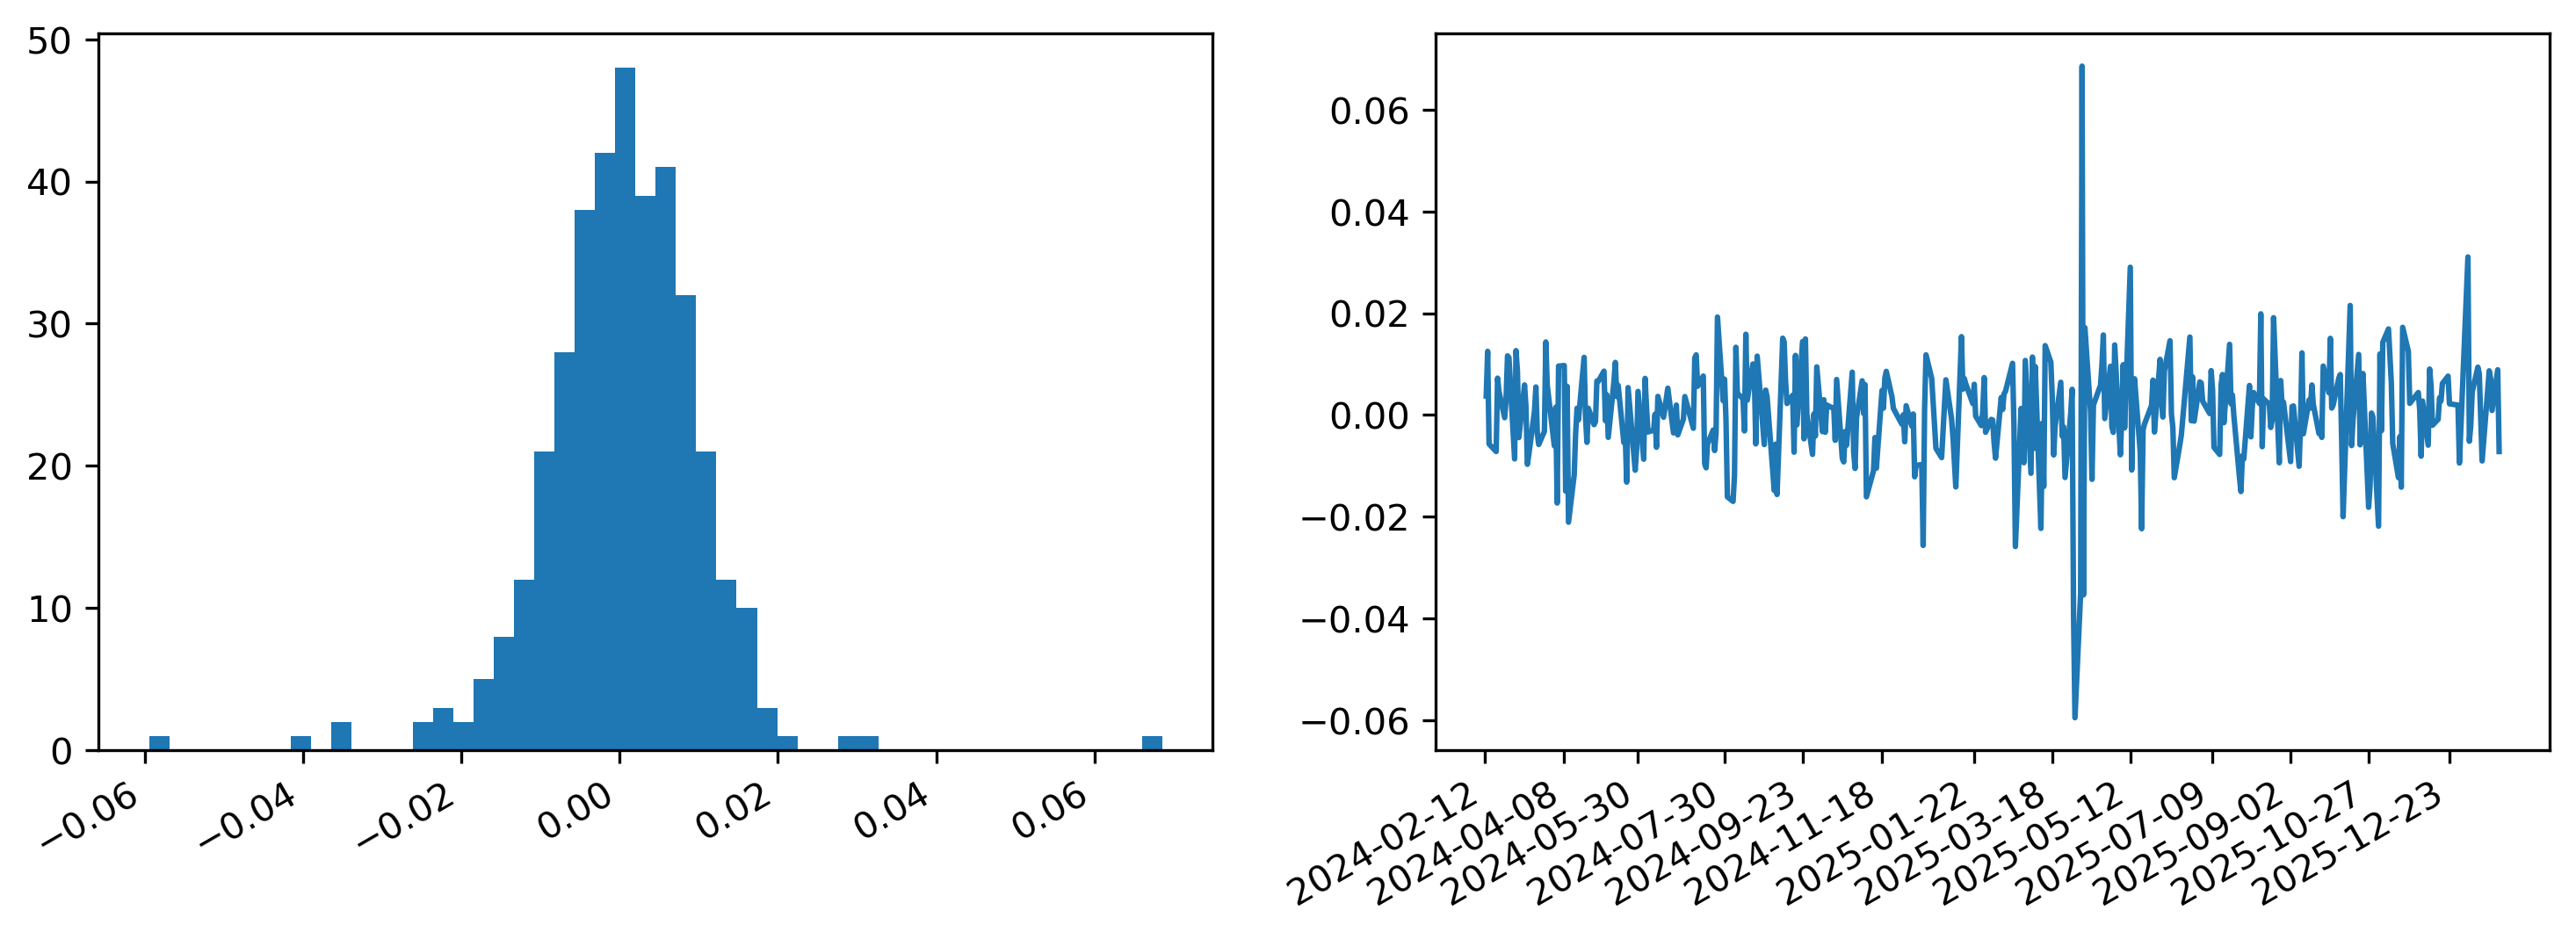

In [30]:
ys = pf_logrets
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 4)
fig.autofmt_xdate();
ax1.hist(ys, bins=50);
ax2.plot(dates[1:], ys);
ax2.set_xticks(dates[::30]);

Gaussian Fit:
Estimated Mean (mu): 0.00
Estimated Standard Deviation (std): 0.01 

Student's-t Fit:
Estimated Degrees of Freedom (df): 4.36
Estimated Location (loc): 0.00
Estimated Scale (scale): 0.01



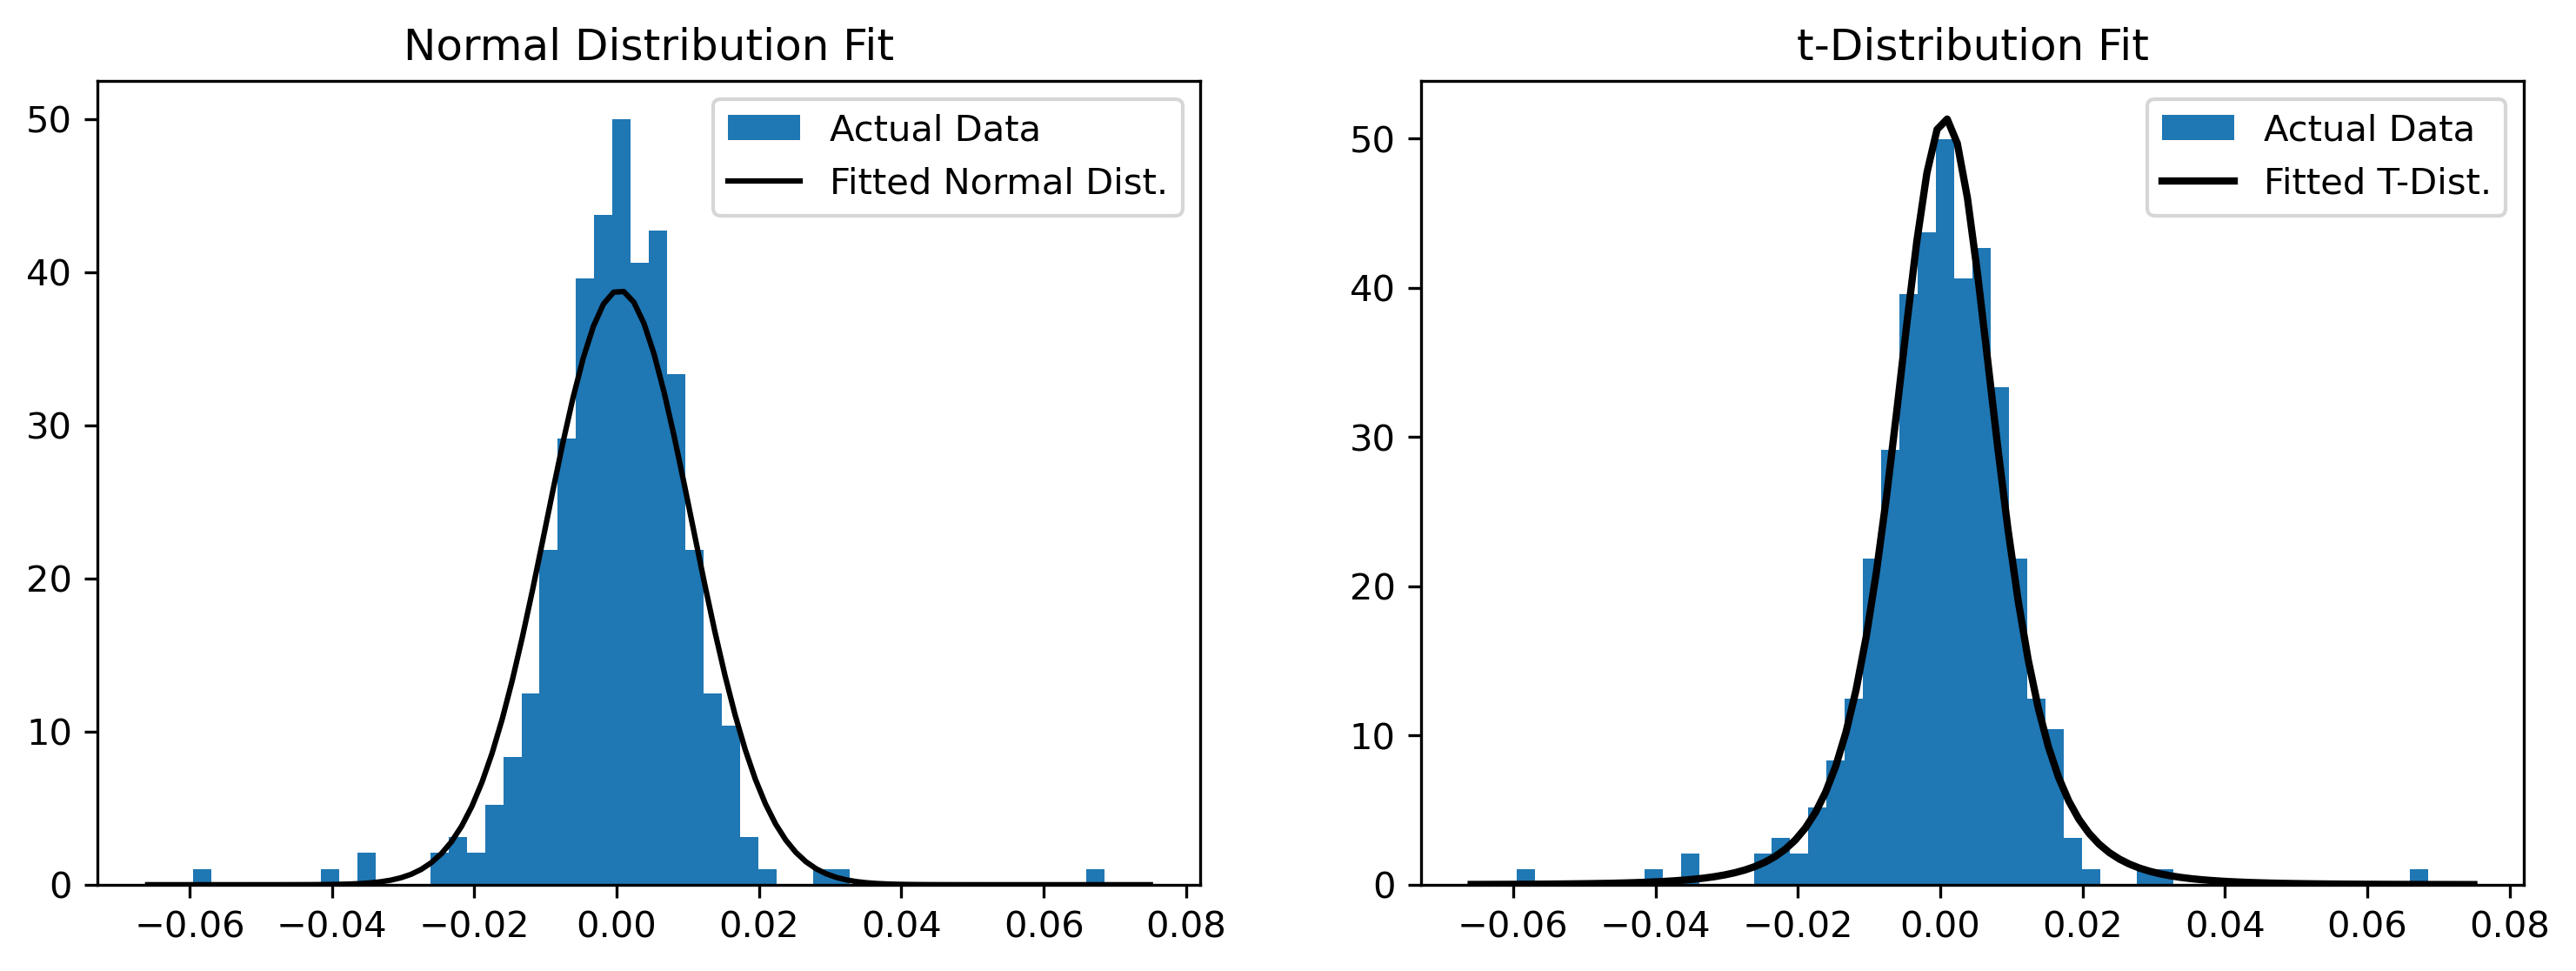

In [31]:
mu, std = sp.stats.norm.fit(pf_logrets)
print('Gaussian Fit:')
print(f"Estimated Mean (mu): {mu:.2f}")
print(f"Estimated Standard Deviation (std): {std:.2f} \n")

df, loc, scale = sp.stats.t.fit(pf_logrets)
print('Student\'s-t Fit:')
print(f"Estimated Degrees of Freedom (df): {df:.2f}")
print(f"Estimated Location (loc): {loc:.2f}")
print(f"Estimated Scale (scale): {scale:.2f}\n")

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

ax1.hist(pf_logrets, bins=50, density=True, label='Actual Data');
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
pnorm = sp.stats.norm.pdf(x, mu, std)
ax1.plot(x, pnorm, 'k', label='Fitted Normal Dist.')
ax1.set_title("Normal Distribution Fit")
ax1.legend();

ax2.hist(pf_logrets, bins=50, density=True, label='Actual Data');
pt = sp.stats.t.pdf(x, df, loc, scale)
ax2.plot(x, pt, 'k', linewidth=2, label='Fitted T-Dist.')
ax2.set_title("t-Distribution Fit")
ax2.legend();

In [ ]:
# calculate VaR and ES
# do KDE/non-parametric fit, again get VaR and ES